---
date: "2026-06-18"
date-modified: last-modified
format:
  html:
    toc: true
---

# Function Spaces: Pointwise and Uniform Convergence

**Motivation:** In many advanced mathematical applications, algorithms, and economic models, we frequently deal with operators that act on *functions* rather than singular numerical values. To rigorously analyze these systems—such as finding a fixed point for a functional operator—we must establish a concrete definition of what it means for a *sequence of functions* to converge toward a *limit function*.

## Two Types of Convergence

### Pointwise Convergence (The Weak Form)
A sequence of functions $f_n : [a,b] \to \mathbb{R}$ is said to converge **pointwise** to a target limit function $f : [a,b] \to \mathbb{R}$ if, at every individual location $x \in [a,b]$, the sequence of evaluated numbers $f_n(x)$ approaches the number $f(x)$.

**Formal Definition:**
$$\forall \epsilon > 0, \forall x \in [a,b], \exists N \in \mathbb{N} \text{ s.t. } n \ge N \implies |f_n(x) - f(x)| < \epsilon$$
*Crucial Detail:* In this definition, the required threshold index $N$ is dependent on **both** the chosen error tolerance $\epsilon$ **and** the specific coordinate $x$.

### Uniform Convergence (The Strong Form)
A sequence $f_n$ converges **uniformly** to $f$ if the speed of convergence does not depend on the spatial coordinate $x$. The sequence must eventually encapsulate the entire graph of the function within a parallel $\epsilon$-band centered around $f$. 
We denote this as $f_n \rightrightarrows f$ or $\text{unif}\lim f_n = f$.

**Formal Definition:**
$$\forall \epsilon > 0, \exists N \in \mathbb{N} \text{ s.t. } \forall x \in [a,b], \text{ if } n \ge N \implies |f_n(x) - f(x)| < \epsilon$$
*Crucial Detail:* Here, $N$ relies **exclusively** on $\epsilon$. A single sufficiently large $N$ acts as a universal threshold for the entire domain $[a,b]$ simultaneously.

---

## Visualizing Convergence & Standard Counterexamples

To grasp why pointwise convergence is considered "weak," we examine classic mathematical counterexamples where a sequence successfully converges pointwise, yet shatters fundamental properties like continuity or the conservation of integral area.

<>:16: SyntaxWarning: invalid escape sequence '\e'
<>:19: SyntaxWarning: invalid escape sequence '\e'
<>:30: SyntaxWarning: invalid escape sequence '\e'
<>:16: SyntaxWarning: invalid escape sequence '\e'
<>:19: SyntaxWarning: invalid escape sequence '\e'
<>:30: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_2613021/490128982.py:16: SyntaxWarning: invalid escape sequence '\e'
  ax1.fill_between(x, f - epsilon, f + epsilon, color='gray', alpha=0.3, label='$\epsilon$-tube')
/tmp/ipykernel_2613021/490128982.py:19: SyntaxWarning: invalid escape sequence '\e'
  ax1.set_title("Uniform Convergence ($\epsilon$-tube)")
/tmp/ipykernel_2613021/490128982.py:30: SyntaxWarning: invalid escape sequence '\e'
  ax2.axhspan(-0.1, 0.1, color='gray', alpha=0.3, label="$\epsilon$-tube")


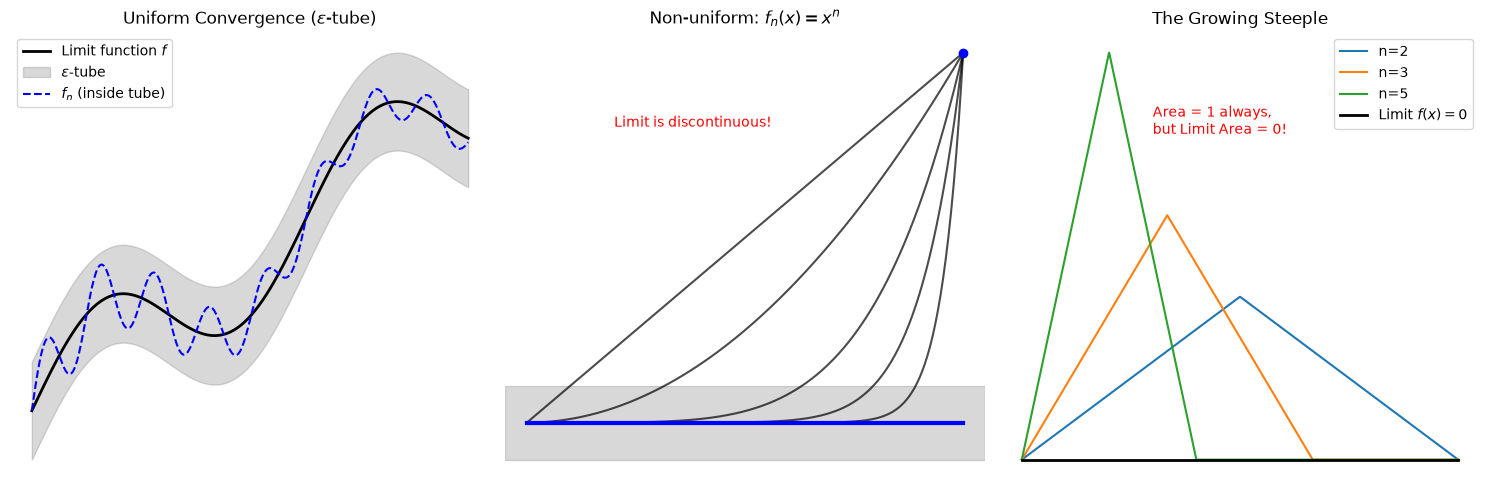

In [1]:
#| label: fig-convergence-counterexamples
#| fig-cap: "Visualizing uniform convergence vs. pointwise counterexamples."
#| warning: false
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('default')
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# --- Plot 1: The Epsilon Tube (Uniform Convergence) ---
ax1 = axes[0]
x = np.linspace(0, 10, 500)
f = np.sin(x) + 0.5 * x  # Target function
epsilon = 0.8
ax1.plot(x, f, 'k-', linewidth=2, label='Limit function $f$')
ax1.fill_between(x, f - epsilon, f + epsilon, color='gray', alpha=0.3, label='$\epsilon$-tube')
fn = f + 0.7 * np.sin(5 * x) * np.exp(-0.1 * x) # A sequence fn inside the tube
ax1.plot(x, fn, 'b--', label='$f_n$ (inside tube)')
ax1.set_title("Uniform Convergence ($\epsilon$-tube)")
ax1.axis('off')
ax1.legend(loc='upper left')

# --- Plot 2: Pointwise but Not Uniform ---
ax2 = axes[1]
x2 = np.linspace(0, 1, 500)
for n in [1, 2, 5, 10, 20]:
    ax2.plot(x2, x2**n, color='black', alpha=0.7)
ax2.plot(x2, np.zeros_like(x2), 'b-', linewidth=3, label="Pointwise Limit f(x)=0 (x<1)")
ax2.plot(1, 1, 'bo') # Discontinuous point at x=1
ax2.axhspan(-0.1, 0.1, color='gray', alpha=0.3, label="$\epsilon$-tube")
ax2.set_title("Non-uniform: $f_n(x) = x^n$")
ax2.text(0.2, 0.8, "Limit is discontinuous!", color='red')
ax2.axis('off')

# --- Plot 3: The Growing Steeple (John Kelley) ---
ax3 = axes[2]
x3 = np.linspace(0, 1, 1000)
def steeple(x, n):
    y = np.zeros_like(x)
    y[(x >= 0) & (x < 1/n)] = n**2 * x[(x >= 0) & (x < 1/n)]
    y[(x >= 1/n) & (x <= 2/n)] = 2*n - n**2 * x[(x >= 1/n) & (x <= 2/n)]
    return y

for n in [2, 3, 5]:
    ax3.plot(x3, steeple(x3, n), label=f'n={n}')
ax3.plot(x3, np.zeros_like(x3), 'k-', linewidth=2, label='Limit $f(x)=0$')
ax3.set_title("The Growing Steeple")
ax3.text(0.3, 4, "Area = 1 always,\nbut Limit Area = 0!", color='red')
ax3.legend()
ax3.axis('off')

plt.tight_layout()
plt.show()


### Analysis of the Counterexamples

1. **The Discontinuous Limit ($f_n(x) = x^n$ on $[0,1]$):** This sequence converges pointwise to a flat $f(x) = 0$ for all $x < 1$, but spikes to $f(1) = 1$ exactly at the boundary. The resulting limit function is fundamentally discontinuous. Uniform convergence is impossible here because no matter how large $n$ becomes, the curve of $x^n$ will always eventually break out of an $\epsilon$-tube as $x$ gets arbitrarily close to 1.
2. **The Growing Steeple:** This sequence constructs a triangular spike of height $n$ and base width $2/n$. For any fixed spatial point $x > 0$, the shrinking base $2/n$ will eventually pass to the left of $x$, causing the function evaluation $f_n(x)$ to drop to 0. Hence, it converges pointwise to the flat zero function $f(x)=0$. The limit is perfectly continuous. However, geometric calculation shows the area under every single steeple $f_n$ is $\frac{1}{2}(\text{base})(\text{height}) = 1$. Meanwhile, the area of the limit function is $0$. This proves that **pointwise convergence is insufficient to preserve integrals**.

---

## Preservation of Continuity

**The Continuity Limit Theorem:** The uniform limit of a sequence of continuous functions is guaranteed to be continuous. 
*(Specifically, if $f_n \rightrightarrows f$ and every $f_n$ is continuous at a point $x_0$, then the limit $f$ is also continuous at $x_0$.)*

**Proof (The $\epsilon/3$ Technique):**
Given an $\epsilon > 0$ and a point $x_0 \in [a,b]$, our goal is to establish the existence of a $\delta > 0$ such that measuring $|x - x_0| < \delta$ strictly forces $|f(x) - f(x_0)| < \epsilon$.

1. Due to uniform convergence ($f_n \rightrightarrows f$), we can select a universally large index $N$ such that for any location $x$ in the domain, $|f_N(x) - f(x)| < \frac{\epsilon}{3}$.
2. We know the specific function $f_N$ is continuous at $x_0$. This allows us to invoke standard continuity: there must be a $\delta > 0$ where if $|x - x_0| < \delta$, it forces $|f_N(x) - f_N(x_0)| < \frac{\epsilon}{3}$.
3. We synthesize these bounds using the triangle inequality to evaluate the limit function $f$:
$$|f(x) - f(x_0)| = |f(x) - f_N(x) + f_N(x) - f_N(x_0) + f_N(x_0) - f(x_0)|$$
$$\le \underbrace{|f(x) - f_N(x)|}_{< \epsilon/3 \text{ (Unif. Conv)}} + \underbrace{|f_N(x) - f_N(x_0)|}_{< \epsilon/3 \text{ (Continuity of } f_N)} + \underbrace{|f_N(x_0) - f(x_0)|}_{< \epsilon/3 \text{ (Unif. Conv)}}$$
$$< \frac{\epsilon}{3} + \frac{\epsilon}{3} + \frac{\epsilon}{3} = \epsilon$$
Consequently, the limit function $f$ maintains continuity at $x_0$. $\square$

---


In [2]:
import warnings
warnings.filterwarnings('ignore')

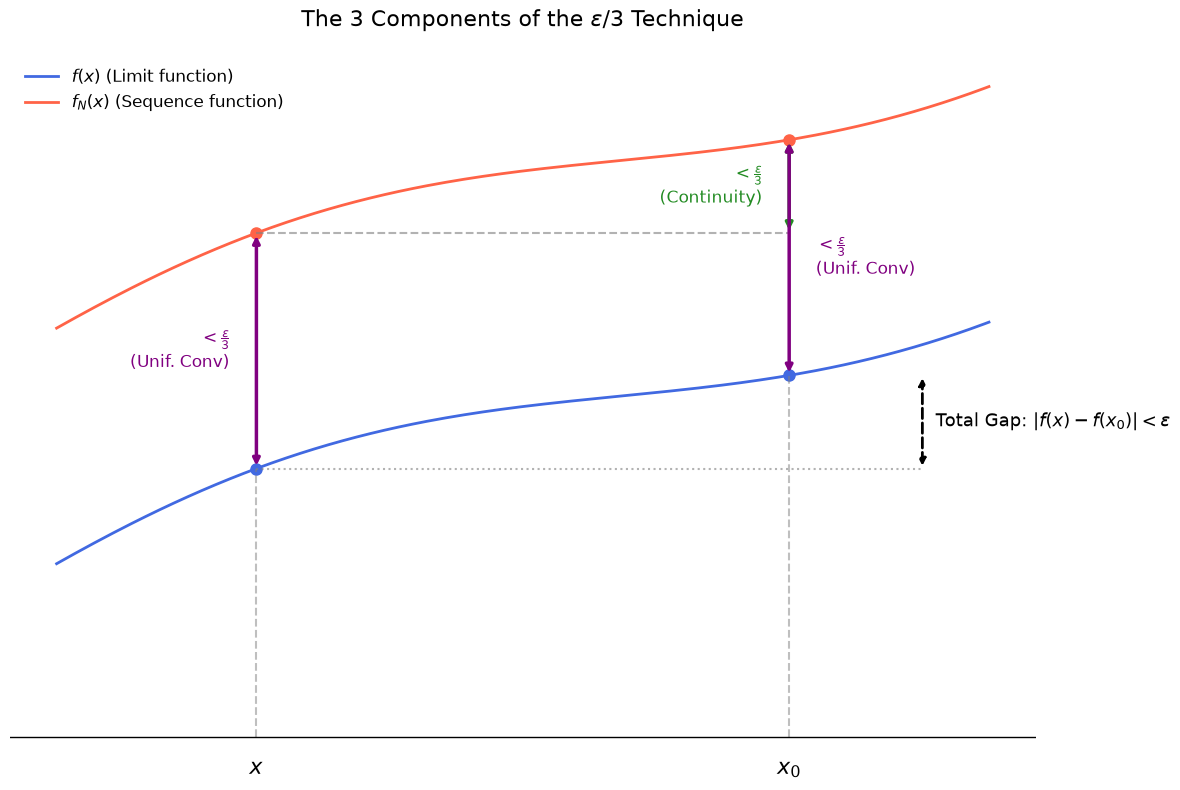

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# 1. Setup the figure
fig, ax = plt.subplots(figsize=(12, 8))

# 2. Define the domain and the functions
x_vals = np.linspace(1, 8, 200)

# Limit function f(x)
f = 0.5 * x_vals + 0.6 * np.sin(0.6 * x_vals) + 1
# Sequence function f_N(x), uniformly shifted
f_N = f + 2.5 

# Plot the curves
ax.plot(x_vals, f, color='royalblue', linewidth=2, label='$f(x)$ (Limit function)')
ax.plot(x_vals, f_N, color='tomato', linewidth=2, label='$f_N(x)$ (Sequence function)')

# 3. Define the points
x_pt = 2.5
x0_pt = 6.5

fx = 0.5 * x_pt + 0.6 * np.sin(0.6 * x_pt) + 1
fNx = fx + 2.5
fx0 = 0.5 * x0_pt + 0.6 * np.sin(0.6 * x0_pt) + 1
fNx0 = fx0 + 2.5

# Plot the four key points
ax.plot([x_pt, x0_pt], [fx, fx0], 'o', color='royalblue', markersize=8)
ax.plot([x_pt, x0_pt], [fNx, fNx0], 'o', color='tomato', markersize=8)

# 4. Draw the 3 Parts of the Epsilon/3 Triangle Inequality

# Part 1: |f(x) - f_N(x)| < e/3 (Uniform Convergence)
ax.annotate('', xy=(x_pt, fNx), xytext=(x_pt, fx),
            arrowprops=dict(arrowstyle='<|-|>', color='purple', lw=2.5))
ax.text(x_pt - 0.2, (fx + fNx)/2, r'$< \frac{\epsilon}{3}$' + '\n(Unif. Conv)', 
        fontsize=12, color='purple', ha='right', va='center')

# Part 2: |f_N(x) - f_N(x0)| < e/3 (Continuity of f_N)
# Draw a horizontal helper line to show the change in y-value visually
ax.plot([x_pt, x0_pt], [fNx, fNx], color='gray', linestyle='--', alpha=0.6)
ax.annotate('', xy=(x0_pt, fNx0), xytext=(x0_pt, fNx),
            arrowprops=dict(arrowstyle='<|-|>', color='forestgreen', lw=2.5))
ax.text(x0_pt - 0.2, (fNx + fNx0)/2, r'$< \frac{\epsilon}{3}$' + '\n(Continuity)', 
        fontsize=12, color='forestgreen', ha='right', va='center')

# Part 3: |f_N(x0) - f(x0)| < e/3 (Uniform Convergence)
ax.annotate('', xy=(x0_pt, fNx0), xytext=(x0_pt, fx0),
            arrowprops=dict(arrowstyle='<|-|>', color='purple', lw=2.5))
ax.text(x0_pt + 0.2, (fx0 + fNx0)/2, r'$< \frac{\epsilon}{3}$' + '\n(Unif. Conv)', 
        fontsize=12, color='purple', ha='left', va='center')

# 5. Show the total bounds |f(x) - f(x0)|
# Horizontal helper line for f(x)
ax.plot([x_pt, x0_pt + 1], [fx, fx], color='gray', linestyle=':', alpha=0.6)
# Vertical total gap
ax.annotate('', xy=(x0_pt + 1, fx0), xytext=(x0_pt + 1, fx),
            arrowprops=dict(arrowstyle='<|-|>', color='black', lw=2, linestyle='--'))
ax.text(x0_pt + 1.1, (fx + fx0)/2, r'Total Gap: $|f(x) - f(x_0)| < \epsilon$', 
        fontsize=13, color='black', ha='left', va='center')

# 6. Format axes and dashed droplines
ax.vlines(x=x_pt, ymin=0, ymax=fx, color='gray', linestyle='--', alpha=0.5)
ax.vlines(x=x0_pt, ymin=0, ymax=fx0, color='gray', linestyle='--', alpha=0.5)

ax.axhline(y=0, color='black', linewidth=1)
ax.text(x_pt, -0.4, '$x$', fontsize=16, ha='center')
ax.text(x0_pt, -0.4, '$x_0$', fontsize=16, ha='center')

# Clean up borders
for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_visible(False)
ax.set_xticks([])
ax.set_yticks([])

plt.title('The 3 Components of the $\epsilon/3$ Technique', fontsize=16, pad=20)
plt.legend(loc='upper left', frameon=False, fontsize=12)

plt.tight_layout()
plt.show()


## The [Metric Space](metric-spaces.ipynb#definition-of-a-metric-space) of Bounded Functions ($C_b$)

Let $C_b = C_b([a,b], \mathbb{R})$ denote the collection of all **bounded** functions mapping the interval $[a,b]$ to $\mathbb{R}$.

**Why does $C_b$ form a [Vector Space](normed-vector-spaces.ipynb#definition-of-a-vector-space)?**
If we take two bounded functions $f, g \in C_b$, there exist finite constants $M_f, M_g$ capping their absolute values. The addition of these functions $(f+g)$ remains bounded because $|f(x) + g(x)| \le M_f + M_g$ via the triangle inequality. Scaling a function $(cf)$ also yields a bounded result capped by $|c|M_f$. Including the inherently bounded zero function confirms that $C_b$ satisfies all structural requirements of a vector space.

**Defining the Supremum Norm:**
We assign a definite "size" to any function $f$ in this space using the supremum norm:
$$\|f\|_{\sup} = \sup \{ |f(x)| : x \in [a,b] \}$$
*(Recall: Every valid mathematical [norm](normed-vector-spaces.ipynb#definition-of-a-norm) naturally creates a corresponding metric by measuring the norm of the difference between two elements).*
Therefore, the induced metric measuring the "distance" between two functions in $C_b$ is:
$$d(f, g) = \|f - g\|_{\sup} = \sup \{ |f(x) - g(x)| : x \in [a,b] \}$$

**Equivalence of the Sup Metric and Uniform Convergence:**
Convergence evaluated through the supremum metric $d$ is mathematically identical to uniform convergence. That is, $d(f_n, f) \to 0$ if and only if $f_n \rightrightarrows f$.

**Proof of Equivalence:** Assume $d(f_n, f) \to 0$. By definition of our metric, this means the value $\sup\{|f_n(x) - f(x)| : x \in [a,b]\}$ approaches $0$. Consequently, for any chosen $\epsilon > 0$, the supremum of the absolute difference must eventually fall below $\epsilon$ for all $n \ge N$. If the *maximum* possible difference across the entire domain is less than $\epsilon$, then the difference at *every* individual point $x$ is simultaneously bounded by $\epsilon$. This flawlessly matches the exact definition of uniform convergence. Applying this same logic in reverse proves the opposite implication. $\square$

### Completeness and Closed Subspaces

**Completeness of the Function Space:**
The function space $C_b$ is completely structurally closed; it forms a [**Complete Metric Space**](completeness.ipynb#complete-metric-spaces).

*(This property is immensely powerful for applied math. It guarantees that if an algorithmic sequence of functions clusters together progressively—forming a Cauchy sequence—a valid limit function is absolutely certain to exist within the space, even if we cannot formulaically compute it!)*

**Proof of Completeness:**

Consider a Cauchy sequence of functions $(f_n)$ residing in $C_b$. 

1. **Establish the pointwise limit:** For any stationary coordinate $x_0$, the evaluations $f_n(x_0)$ form a standard Cauchy sequence of real numbers, constrained by $|f_n(x_0) - f_m(x_0)| \le d(f_n, f_m)$. Because the real number line $\mathbb{R}$ is complete, this numerical sequence must converge to some real value. We define our target limit function by these converging points: $f(x) = \lim_{n \to \infty} f_n(x)$.
2. **Elevate to uniform convergence:** Given an $\epsilon > 0$, the Cauchy nature of $(f_n)$ guarantees an index $N$ where for any $n, m \ge N$, the spatial distance $|f_n(x) - f_m(x)| < \epsilon / 2$ holds universally across all $x$. By pushing $m \to \infty$ inside this inequality, we transition to $|f_n(x) - f(x)| \le \epsilon/2 < \epsilon$. Because this universal upper bound applies for all $n \ge N$ irrespective of $x$, the convergence $f_n \rightrightarrows f$ is strictly uniform.
3. **Verify domain inclusion ($f \in C_b$):** Since the specific function $f_N$ is bounded, and our limit function $f$ cannot stray further than $\epsilon$ from it, $f$ itself is undeniably bounded. Therefore, $f$ belongs to $C_b$. $\square$

**$C^0$ as a Closed Subset:**
Let $C^0$ denote the specific subspace consisting exclusively of *continuous* functions. We have already proven that the uniform limit of any sequence of continuous functions is itself continuous. This implies that if a sequence entirely within $C^0$ converges, its limit function cannot escape into the broader bounded space; it must strictly remain inside $C^0$. Because $C^0$ successfully captures all of its own limit points, it constitutes a **closed subset** of $C_b$. By fundamental topological axioms, any closed subset residing inside a complete metric space inherits completeness. Consequently, $C^0$ is also a complete metric space in its own right. $\square$

---

## Infinite Series of Functions

When transitioning from sequences to infinite series of functions, we analyze the sequence of their partial sums, $F_n(x) = \sum_{k=0}^n f_k(x)$. If this sequence of partial sums converges uniformly, the infinite series is declared to converge uniformly.

**The Weierstrass M-Test:**
Suppose $\sum M_k$ is a converging series of positive real numbers. If a sequence of bounded functions $f_k \in C_b$ can be absolutely capped such that their sizes never exceed these constants ($\|f_k\|_{\sup} \le M_k$ for all $k$), then the infinite function series $\sum f_k(x)$ is guaranteed to converge uniformly and absolutely.

**Proof of the M-Test:** Because the numerical series $\sum M_k$ converges, its partial sums form a Cauchy sequence. This dictates that the tail of the series, $\sum_{k=m+1}^n M_k$, can be made strictly less than $\epsilon$ for sufficiently massive indices $m$ and $n$.
Evaluating the distance between the partial sums of our function series yields:
$$d(F_n, F_m) \le \sum_{k=m+1}^n \|f_k\|_{\sup} \le \sum_{k=m+1}^n M_k < \epsilon$$
This confirms that the sequence of partial function sums $(F_n)$ is Cauchy within the complete space $C_b$, thereby proving it converges uniformly. $\square$

---

## Preservation of Calculus Operations

Uniform convergence acts as the vital, mathematically secure bridge that allows us to legally commute limits with the fundamental operations of calculus. 

**Commutativity of Limits and Integrals:**
The uniform limit of a sequence of Riemann integrable functions is guaranteed to be Riemann integrable itself, and critically, the integral of the limit function equals the limit of the integrals:
$$\lim_{n \to \infty} \int_a^b f_n(x)dx = \int_a^b \left( \text{unif}\lim_{n \to \infty} f_n(x) \right) dx$$

**Proof:** Let $f_n$ be a sequence of Riemann integrable functions that converge uniformly to $f$. According to Lebesgue's integrability criterion, each individual $f_n$ must be bounded and possess a set of discontinuities—let's call it $Z_n$—that exhibits a measure of zero. 
Because the convergence to $f$ is uniform, $f$ inherits continuity everywhere except potentially on the cumulative union of all these discontinuity sets, denoted as $\bigcup_{n=1}^\infty Z_n$. A core principle of measure theory dictates that the countable union of measure-zero sets fundamentally remains a set of measure zero. Therefore, $f$ is continuous almost everywhere. Combined with the fact that uniform convergence preserves boundedness, $f$ perfectly satisfies the criteria to be Riemann integrable.

To verify that the integral values converge, we construct a bound on their absolute difference:
$$\left| \int_a^b f(x)dx - \int_a^b f_n(x)dx \right| = \left| \int_a^b (f(x) - f_n(x)) dx \right|$$
$$\le \int_a^b |f(x) - f_n(x)| dx \le \int_a^b \|f - f_n\|_{\sup} dx = \|f - f_n\|_{\sup}(b - a)$$
Since we know $\|f - f_n\|_{\sup} \to 0$ as $n \to \infty$ due to uniform convergence, the upper bound crushes the difference to exactly zero, proving the integrals converge. $\square$

**Preservation of Differentiability (The Strict Case):**
Derivatives are much more volatile than integrals. The uniform limit of a sequence of differentiable functions $f_n$ is differentiable **only if** the sequence of their derivatives $(f'_n)$ is also known to converge uniformly. 
*(Merely knowing that $f_n \rightrightarrows f$ provides absolutely zero guarantee that the limit function $f$ will be differentiable—or even that the slopes will align if it is).*